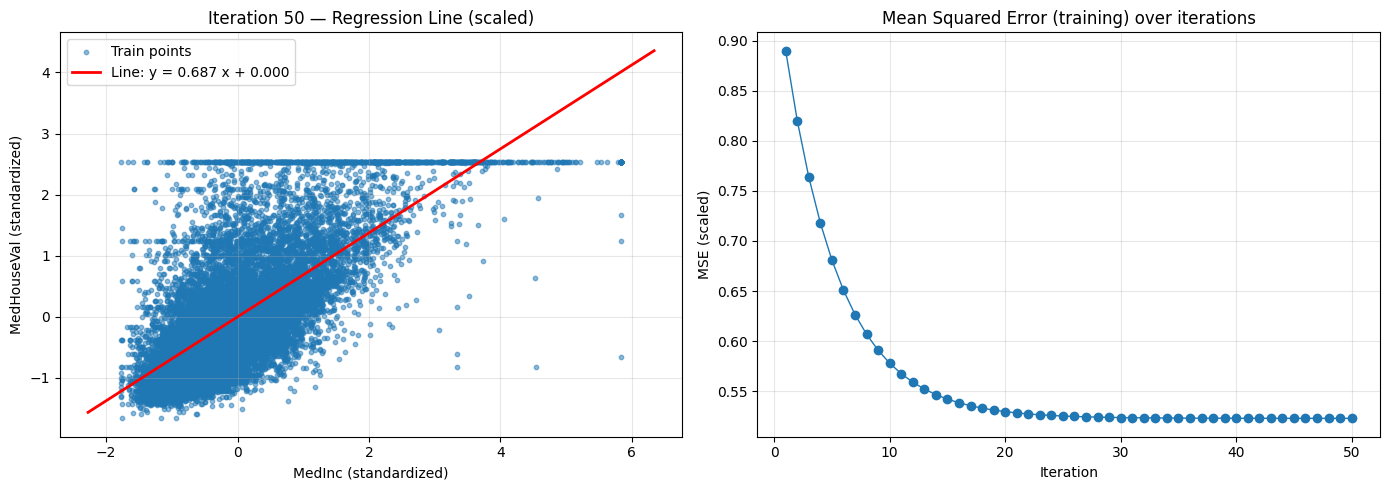

Finished 50 iterations. Learning rate=0.05
Final params (scaled space): w=0.687178, b=0.000000
Train MSE (scaled): 0.523019
Test  MSE (scaled): 0.530398

Example: mapping a few points back to original units (first 5 shown):
scaled x=-2.275 -> orig x=-0.452 ; scaled y=-1.564 -> orig y=0.264
scaled x=-2.232 -> orig x=-0.370 ; scaled y=-1.534 -> orig y=0.298
scaled x=-2.189 -> orig x=-0.287 ; scaled y=-1.504 -> orig y=0.333
scaled x=-2.146 -> orig x=-0.205 ; scaled y=-1.474 -> orig y=0.367
scaled x=-2.102 -> orig x=-0.122 ; scaled y=-1.445 -> orig y=0.402


In [3]:
# ==== ALL CODE GENERATED using Free GPT 3.0 Model =====

#  ===================================
#  Univariate LR with Gradient Descent  (Setting: 50, 0.05, 1/2/5)
#  ===================================

# ---- Imports ----
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import clear_output, display
import time
import random

# ---- Helper to parse user input with defaults ----
def get_input(prompt, default, cast):
    s = input(f"{prompt} (default {default}): ").strip()
    if s == "":
        return default
    try:
        return cast(s)
    except:
        print("Invalid input — using default:", default)
        return default

# ---- 1) Load data (California housing) and select one feature ----
# (scikit-learn's fetch_california_housing). See scikit-learn docs.
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Pick a single feature: 'MedInc' (median income)
X = df[['MedInc']].values   # shape (n_samples, 1)
y = df['MedHouseVal'].values  # target (median house value)

# Optional: sample to a smaller subset for interactive speed (uncomment if desired)
# random_state = 42
# idx = np.random.RandomState(random_state).choice(len(X), size=1500, replace=False)
# X = X[idx]; y = y[idx]

# ---- 2) Train-test split and scaling ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)      # scaled feature (n_train,1)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_s  = scaler_y.transform(y_test.reshape(-1,1)).ravel()

# For plotting convenience we'll work in scaled coordinates (labels indicate scaled)
# If you prefer original units, you can transform line endpoints back with scaler_y.inverse_transform.

# ---- 3) Ask user for hyperparameters ----
print("Enter gradient descent settings:")
n_iters = get_input("Number of iterations", 100, int)
lr = get_input("Learning rate (e.g., 0.01)", 0.01, float)
plot_every = get_input("Plot every k iterations (set 1 to plot every iter)", 1, int)

# ---- 4) Loss function (MSE) and gradient step ----
def mse_loss(Xs, ys, w, b):
    # Xs: (n,1) ; ys: (n,)
    y_pred = w * Xs.ravel() + b
    return np.mean((y_pred - ys) ** 2)

def gradient_step(Xs, ys, w, b, lr):
    n = len(ys)
    y_pred = w * Xs.ravel() + b
    # gradients (derivative of MSE)
    dw = (2.0 / n) * np.dot((y_pred - ys), Xs.ravel())
    db = (2.0 / n) * np.sum(y_pred - ys)
    w_new = w - lr * dw
    b_new = b - lr * db
    return w_new, b_new, dw, db

# ---- 5) Initialize parameters ----
rng = np.random.RandomState(0)
w = rng.normal(scale=0.01)   # small random init
b = 0.0

# history
loss_hist = []
iters_hist = []
w_hist = []
b_hist = []

# ---- 6) Training loop with live plotting ----
# We'll use IPython.display.clear_output to update plots in Colab.
for it in range(1, n_iters + 1):
    w, b, dw, db = gradient_step(X_train_s, y_train_s, w, b, lr)
    loss = mse_loss(X_train_s, y_train_s, w, b)

    # store history
    loss_hist.append(loss)
    iters_hist.append(it)
    w_hist.append(w)
    b_hist.append(b)

    # Plotting
    if (it % plot_every == 0) or (it == n_iters):
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

        # Left: data scatter + regression line (scaled units)
        ax1.scatter(X_train_s, y_train_s, s=10, alpha=0.5, label='Train points')
        xs_line = np.linspace(X_train_s.min()-0.5, X_train_s.max()+0.5, 200)
        ys_line = w * xs_line + b
        ax1.plot(xs_line, ys_line, color='red', lw=2, label=f'Line: y = {w:.3f} x + {b:.3f}')
        ax1.set_title(f'Iteration {it} — Regression Line (scaled)')
        ax1.set_xlabel('MedInc (standardized)')
        ax1.set_ylabel('MedHouseVal (standardized)')
        ax1.legend()
        ax1.grid(alpha=0.3)

        # Right: MSE over iterations
        ax2.plot(iters_hist, loss_hist, marker='o', lw=1)
        ax2.set_title('Mean Squared Error (training) over iterations')
        ax2.set_xlabel('Iteration')
        ax2.set_ylabel('MSE (scaled)')
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        display(fig)
        plt.close(fig)
        # small pause so the frontend updates smoothly
        time.sleep(0.01)

# ---- 7) Final evaluation on test set (scaled) and print parameters ----
final_train_loss = mse_loss(X_train_s, y_train_s, w, b)
final_test_loss = mse_loss(X_test_s, y_test_s, w, b)
print(f"Finished {n_iters} iterations. Learning rate={lr}")
print(f"Final params (scaled space): w={w:.6f}, b={b:.6f}")
print(f"Train MSE (scaled): {final_train_loss:.6f}")
print(f"Test  MSE (scaled): {final_test_loss:.6f}")

# If you'd like to see the regression line in original units:
# Transform two endpoints back
x_orig_endpoints = scaler_X.inverse_transform(xs_line.reshape(-1,1)).ravel()
y_line_orig_scaled = ys_line.reshape(-1,1)
y_line_orig = scaler_y.inverse_transform(y_line_orig_scaled).ravel()

# Print example mapping (first 5)
print("\nExample: mapping a few points back to original units (first 5 shown):")
for xi_s, yi_s, xi_o, yi_o in zip(xs_line[:5], ys_line[:5], x_orig_endpoints[:5], y_line_orig[:5]):
    print(f"scaled x={xi_s:.3f} -> orig x={xi_o:.3f} ; scaled y={yi_s:.3f} -> orig y={yi_o:.3f}")


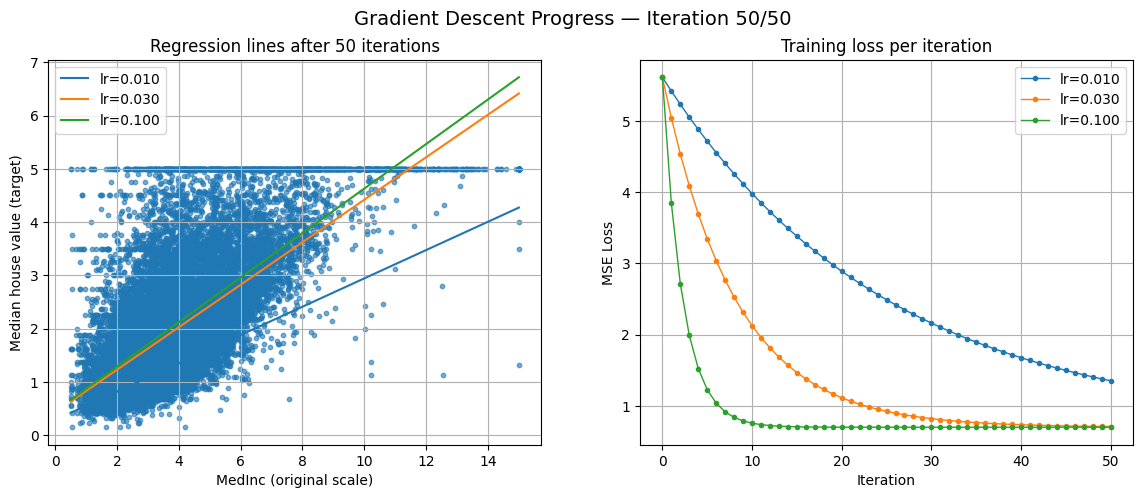

Finished gradient descent.
Final parameters (theta0, theta1) for each learning rate:
  lr=0.01000  =>  theta0 = 1.31525,  theta1 = 0.50484  (model: y = theta0 + theta1 * (X - mean)/std)
  lr=0.03000  =>  theta0 = 1.97479,  theta1 = 0.75800  (model: y = theta0 + theta1 * (X - mean)/std)
  lr=0.10000  =>  theta0 = 2.06853,  theta1 = 0.79398  (model: y = theta0 + theta1 * (X - mean)/std)


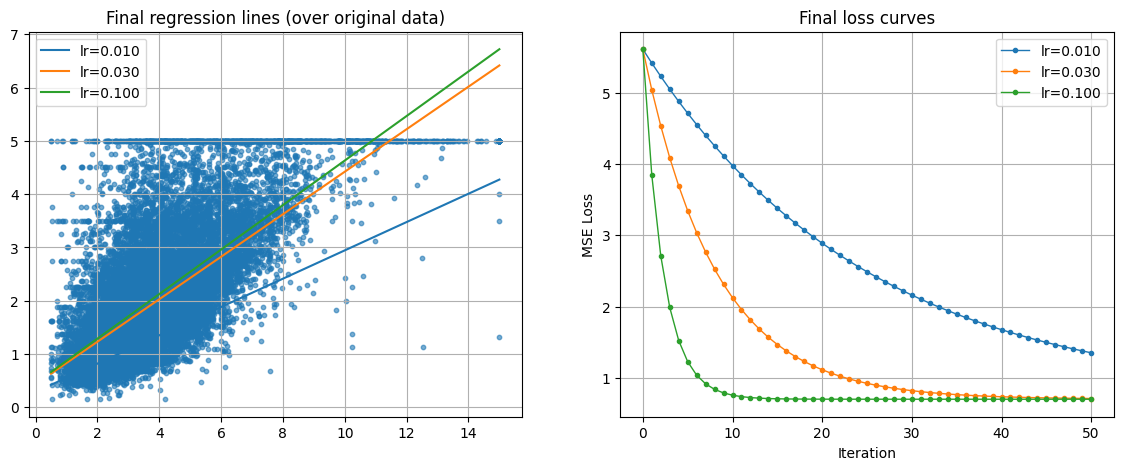

In [4]:
#  ===========================================
#   Univariate LR with Multiple Learning Rates  (Setting: 50, default, 1/2/5)
#  ===========================================


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from IPython.display import clear_output, display
from time import sleep

# ---------------------------
# 1) Load California housing and pick one feature (MedInc)
# ---------------------------
data = fetch_california_housing()
X_all = data.data
feature_names = data.feature_names
# We'll use 'MedInc' (median income) which is index 0 in this dataset
feat_idx = feature_names.index('MedInc')
X = X_all[:, feat_idx].reshape(-1)   # shape (n,)
y = data.target.reshape(-1)          # target median house value

n = X.shape[0]

# ---------------------------
# 2) Feature scaling for X (important for stable gradient descent)
#    We scale X to zero mean and unit std. We'll not scale y.
# ---------------------------
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

# ---------------------------
# Utility: prediction function (works with scaled X)
# ---------------------------
def predict_from_theta(theta, x_scaled):
    """theta: (theta0, theta1), x_scaled: array"""
    return theta[0] + theta[1] * x_scaled

# ---------------------------
# 3) User inputs: number of iterations and (optionally) learning rates
# ---------------------------
try:
    num_iters_input = input("Enter number of iterations (default 100): ").strip()
    num_iters = int(num_iters_input) if num_iters_input else 100
except Exception:
    print("Invalid input for iterations. Using default 100.")
    num_iters = 100

# default three learning rates (you can enter comma-separated)
default_lrs = [0.01, 0.03, 0.1]
lrs_input = input(f"Enter 3 learning rates separated by commas (default {default_lrs}): ").strip()
if lrs_input:
    try:
        lrs = [float(x) for x in lrs_input.split(",")][:3]
        # if user gave fewer than 3, fill with defaults
        while len(lrs) < 3:
            lrs.append(default_lrs[len(lrs)])
    except Exception:
        print("Couldn't parse learning rates. Using defaults.")
        lrs = default_lrs
else:
    lrs = default_lrs

lrs = list(lrs)  # ensure list
n_lrs = len(lrs)

print(f"\nRunning gradient descent for {num_iters} iterations with learning rates: {lrs}\n")

# ---------------------------
# 4) Initialize parameters (theta0 intercept, theta1 slope) and loss history
# ---------------------------
thetas = np.zeros((n_lrs, 2))  # each row: [theta0, theta1] for one LR
loss_hist = [[] for _ in range(n_lrs)]

# compute initial loss (iteration 0, with theta zeros)
for i in range(n_lrs):
    preds0 = predict_from_theta(thetas[i], X_scaled)
    loss0 = np.mean((preds0 - y) ** 2)   # MSE
    loss_hist[i].append(loss0)

# ---------------------------
# 5) Gradient descent loop
# ---------------------------
# To avoid extremely long animation in notebooks, automatically throttle updates if iterations are huge.
max_frames = 300  # don't render more than this many figure-updates by default
update_every = 1
if num_iters > max_frames:
    update_every = max(1, num_iters // max_frames)
    print(f"Note: num_iters={num_iters} is large — plotting will update every {update_every} iterations to keep notebook responsive.")

# x-values for plotting regression lines (on original X scale)
x_vals = np.linspace(X.min(), X.max(), 200)
x_vals_scaled = (x_vals - X_mean) / X_std  # scaled version used in predictions

for it in range(1, num_iters + 1):
    # perform one gradient update per learning rate
    for i, lr in enumerate(lrs):
        theta0, theta1 = thetas[i]
        preds = predict_from_theta((theta0, theta1), X_scaled)  # predictions using current theta
        error = preds - y
        # gradients (d/dtheta) of MSE (1/n sum (error^2)) -> (2/n) * sum(error * d_pred/d_theta)
        grad0 = (2.0 / n) * np.sum(error)              # derivative w.r.t. theta0 (d_pred/d_theta0 = 1)
        grad1 = (2.0 / n) * np.sum(error * X_scaled)   # derivative w.r.t. theta1 (d_pred/d_theta1 = x_scaled)
        # gradient descent update
        theta0_new = theta0 - lr * grad0
        theta1_new = theta1 - lr * grad1
        thetas[i] = [theta0_new, theta1_new]
        # compute & save loss after update
        preds_new = predict_from_theta(thetas[i], X_scaled)
        loss_new = np.mean((preds_new - y) ** 2)
        loss_hist[i].append(loss_new)

    # update the notebook plots every `update_every` iterations (or on last iteration)
    if (it % update_every == 0) or (it == num_iters):
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # left plot: data scatter + regression lines (all lrs simultaneously)
        axes[0].scatter(X, y, s=10, alpha=0.6)
        for i, lr in enumerate(lrs):
            theta0, theta1 = thetas[i]
            # get predictions on the original-scale x values by predicting on scaled x
            y_line = predict_from_theta((theta0, theta1), x_vals_scaled)
            axes[0].plot(x_vals, y_line, label=f'lr={lr:.3f}')
        axes[0].set_xlabel('MedInc (original scale)')
        axes[0].set_ylabel('Median house value (target)')
        axes[0].set_title(f'Regression lines after {it} iterations')
        axes[0].legend()
        axes[0].grid(True)

        # right plot: loss curves (MSE) over iterations
        for i, lr in enumerate(lrs):
            axes[1].plot(range(len(loss_hist[i])), loss_hist[i], marker='o', linewidth=1, markersize=3, label=f'lr={lr:.3f}')
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('MSE Loss')
        axes[1].set_title('Training loss per iteration')
        axes[1].legend()
        axes[1].grid(True)

        fig.suptitle(f'Gradient Descent Progress — Iteration {it}/{num_iters}', fontsize=14)
        display(fig)
        plt.close(fig)
        # small pause so the notebook has time to render — adjust if too slow
        sleep(0.08)

# ---------------------------
# 6) Final results printout
# ---------------------------
print("Finished gradient descent.\nFinal parameters (theta0, theta1) for each learning rate:")
for i, lr in enumerate(lrs):
    print(f"  lr={lr:.5f}  =>  theta0 = {thetas[i,0]:.5f},  theta1 = {thetas[i,1]:.5f}  (model: y = theta0 + theta1 * (X - mean)/std)")

# Optionally show final static plot again (one last time)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].scatter(X, y, s=10, alpha=0.6)
for i, lr in enumerate(lrs):
    y_line = predict_from_theta((thetas[i,0], thetas[i,1]), x_vals_scaled)
    axes[0].plot(x_vals, y_line, label=f'lr={lr:.3f}')
axes[0].set_title('Final regression lines (over original data)')
axes[0].legend()
axes[0].grid(True)

for i, lr in enumerate(lrs):
    axes[1].plot(range(len(loss_hist[i])), loss_hist[i], marker='o', linewidth=1, markersize=3, label=f'lr={lr:.3f}')
axes[1].set_title('Final loss curves')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True)
plt.show()


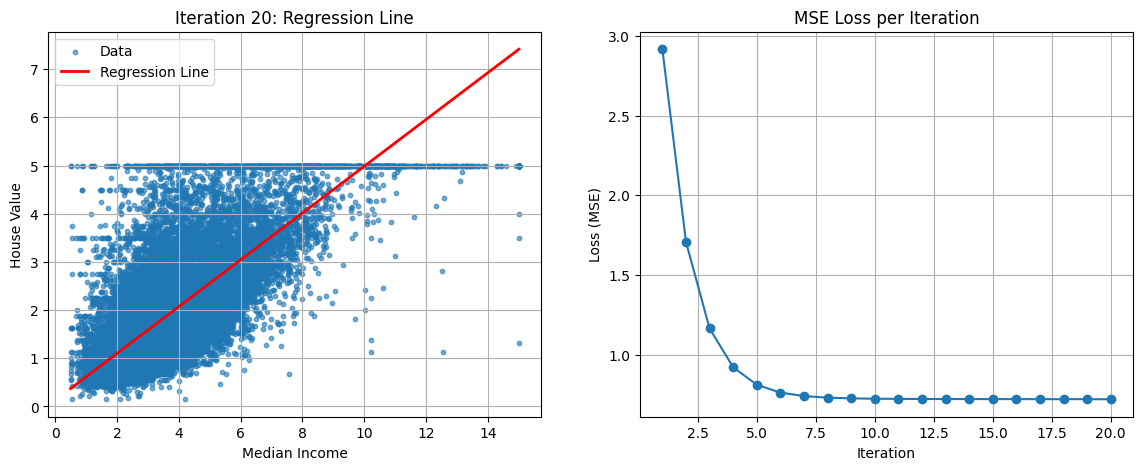


Final Model Parameters:
Intercept: 0.1290
Coefficient (slope): 0.4857


In [6]:
#  ====================================
#  Univariate LR with buit-in function  (Setting: 20, 0.000001)
#  ====================================

# Univariate Linear Regression with sklearn (SGDRegressor) in Google Colab
# Iteration by iteration plots (regression line + loss curve)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import clear_output, display
from time import sleep

# -------------------------------
# Load California housing dataset (MedInc only)
# -------------------------------
data = fetch_california_housing()
X = data.data[:, [0]]   # Median Income (as 2D for sklearn)
y = data.target

# -------------------------------
# User input: iterations & learning rate
# -------------------------------
try:
    num_iters = int(input("Enter number of iterations (default 50): ") or 50)
except:
    num_iters = 50

try:
    lr = float(input("Enter learning rate (default 0.01): ") or 0.01)
except:
    lr = 0.01

print(f"\nRunning {num_iters} iterations with learning rate {lr}\n")

# -------------------------------
# Initialize SGDRegressor (linear regression with gradient descent)
# -------------------------------
sgd = SGDRegressor(max_iter=1, tol=None, learning_rate="constant", eta0=lr, random_state=42)

loss_history = []

# For regression line plotting
x_vals = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

# -------------------------------
# Iterative training & plotting
# -------------------------------
for it in range(1, num_iters + 1):
    # One step of training
    sgd.partial_fit(X, y)

    # Predictions
    y_pred = sgd.predict(X)
    loss = mean_squared_error(y, y_pred)
    loss_history.append(loss)

    # Plot side by side
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: scatter + regression line
    axes[0].scatter(X, y, s=10, alpha=0.6, label="Data")
    y_line = sgd.predict(x_vals)
    axes[0].plot(x_vals, y_line, color="red", linewidth=2, label="Regression Line")
    axes[0].set_title(f"Iteration {it}: Regression Line")
    axes[0].set_xlabel("Median Income")
    axes[0].set_ylabel("House Value")
    axes[0].legend()
    axes[0].grid(True)

    # Right: loss curve
    axes[1].plot(range(1, len(loss_history) + 1), loss_history, marker='o')
    axes[1].set_title("MSE Loss per Iteration")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Loss (MSE)")
    axes[1].grid(True)

    display(fig)
    plt.close(fig)
    sleep(0.2)  # Adjust animation speed

# -------------------------------
# Final Parameters
# -------------------------------
print("\nFinal Model Parameters:")
print(f"Intercept: {sgd.intercept_[0]:.4f}")
print(f"Coefficient (slope): {sgd.coef_[0]:.4f}")


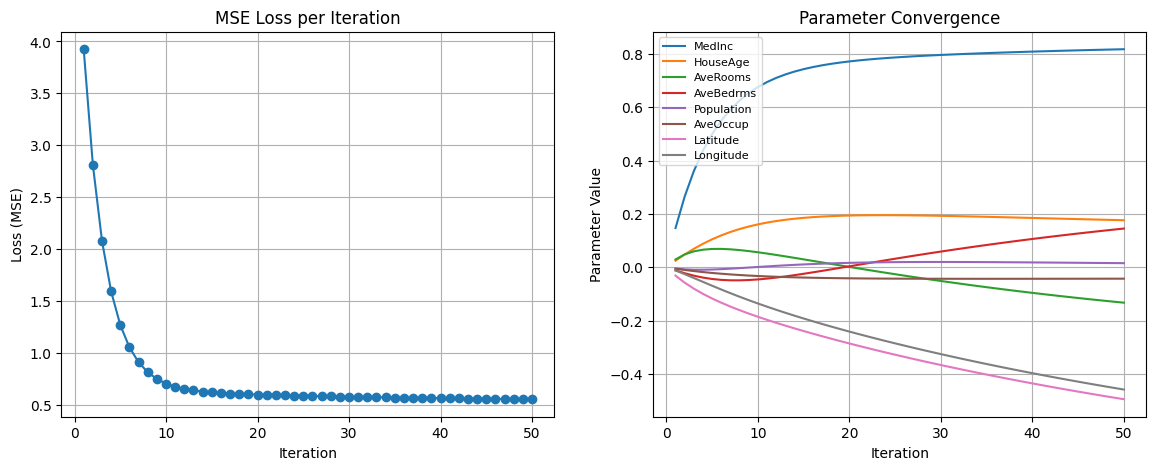


Final Model Parameters:
Intercept: 2.0691
MedInc: 0.8174
HouseAge: 0.1764
AveRooms: -0.1326
AveBedrms: 0.1453
Population: 0.0154
AveOccup: -0.0427
Latitude: -0.4945
Longitude: -0.4582


In [7]:
#  ===============================
#   Multivariate Linear Regression (Setting: 50, 0.00001)
#  ===============================

# Multivariate Linear Regression with SGDRegressor in Google Colab
# Shows iteration-by-iteration Loss curve + Coefficient convergence

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import clear_output, display
from time import sleep

# -------------------------------
# 1) Load California housing dataset (multivariate)
# -------------------------------
data = fetch_california_housing()
X = data.data   # all 8 features
y = data.target
feature_names = data.feature_names

# -------------------------------
# 2) Feature scaling
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 3) User input for iterations & learning rate
# -------------------------------
try:
    num_iters = int(input("Enter number of iterations (default 50): ") or 50)
except:
    num_iters = 50

try:
    lr = float(input("Enter learning rate (default 0.01): ") or 0.01)
except:
    lr = 0.01

print(f"\nRunning {num_iters} iterations with learning rate {lr}\n")

# -------------------------------
# 4) Initialize SGDRegressor
# -------------------------------
sgd = SGDRegressor(max_iter=1, tol=None, learning_rate="constant", eta0=lr, random_state=42)

loss_history = []
coef_history = []

# -------------------------------
# 5) Iterative training & plotting
# -------------------------------
for it in range(1, num_iters + 1):
    # Train one step
    sgd.partial_fit(X_scaled, y)

    # Predictions and loss
    y_pred = sgd.predict(X_scaled)
    loss = mean_squared_error(y, y_pred)
    loss_history.append(loss)

    # Store coefficient history
    coef_history.append(sgd.coef_.copy())

    # -------------------------------
    # Plot: Loss curve + Coefficient convergence
    # -------------------------------
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Loss curve
    axes[0].plot(range(1, len(loss_history) + 1), loss_history, marker='o')
    axes[0].set_title("MSE Loss per Iteration")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Loss (MSE)")
    axes[0].grid(True)

    # Right: Coefficient convergence
    coef_array = np.array(coef_history)  # shape: (iterations, n_features)
    for j in range(coef_array.shape[1]):
        axes[1].plot(range(1, len(coef_history) + 1), coef_array[:, j], label=feature_names[j])
    axes[1].set_title("Parameter Convergence")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Parameter Value")
    axes[1].legend(loc="best", fontsize=8)
    axes[1].grid(True)

    display(fig)
    plt.close(fig)
    sleep(0.3)  # control animation speed

# -------------------------------
# 6) Final Parameters
# -------------------------------
print("\nFinal Model Parameters:")
print(f"Intercept: {sgd.intercept_[0]:.4f}")
for fname, coef in zip(feature_names, sgd.coef_):
    print(f"{fname}: {coef:.4f}")


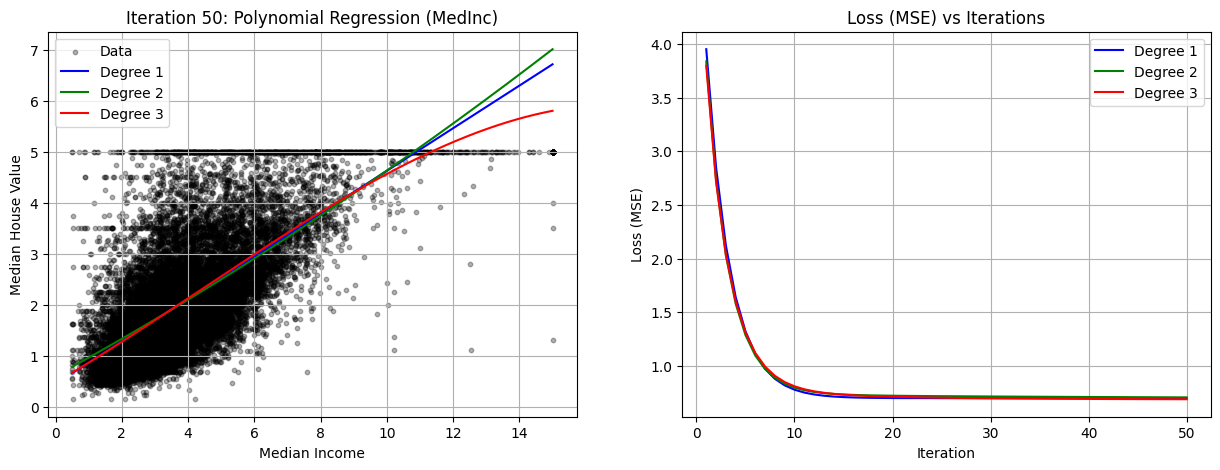

Training complete ✅


In [8]:
#  ================================================================
#   Polynomial Regression - California Housing Med Income feature (Setting: 50, 0.00001)
#  ================================================================

# Polynomial Regression on California Housing (Median Income vs House Value)
# Iteration-by-iteration visualization with user input in Google Colab

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import clear_output, display
import time

# -------------------------------
# 1) Load California Housing dataset (Median Income feature only)
# -------------------------------
data = fetch_california_housing()
X = data.data[:, [0]]   # Median Income
y = data.target         # Median House Value

# -------------------------------
# 2) User input for iterations and learning rate
# -------------------------------
num_iters = int(input("Enter number of iterations: "))
eta = float(input("Enter learning rate (e.g., 0.01): "))

# -------------------------------
# 3) Prepare polynomial features (degrees 1–4) and scaling
# -------------------------------
degrees = [1, 2, 3]
poly_features = {d: PolynomialFeatures(degree=d, include_bias=False) for d in degrees}
scalers = {d: StandardScaler() for d in degrees}

X_poly = {d: poly_features[d].fit_transform(X) for d in degrees}
X_scaled = {d: scalers[d].fit_transform(X_poly[d]) for d in degrees}

# -------------------------------
# 4) Initialize SGD models for each degree
# -------------------------------
sgd_models = {
    d: SGDRegressor(max_iter=1, tol=None, learning_rate="constant",
                    eta0=eta, random_state=42)
    for d in degrees
}
loss_history = {d: [] for d in degrees}

# -------------------------------
# 5) Grid for smooth regression curves
# -------------------------------
X_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_grid_poly = {d: poly_features[d].transform(X_grid) for d in degrees}
X_grid_scaled = {d: scalers[d].transform(X_grid_poly[d]) for d in degrees}

# -------------------------------
# 6) Iterative training loop
# -------------------------------
colors = {1: "blue", 2: "green", 3: "red", 4: "purple"}

for iteration in range(1, num_iters + 1):
    # Train one step and record loss
    for d in degrees:
        sgd_models[d].partial_fit(X_scaled[d], y)
        y_pred = sgd_models[d].predict(X_scaled[d])
        loss = mean_squared_error(y, y_pred)
        loss_history[d].append(loss)

    # -------------------------------
    # Visualization
    # -------------------------------
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Left: Regression plots (data + polynomial models)
    axes[0].scatter(X, y, color="black", alpha=0.3, label="Data", s=10)
    for d in degrees:
        y_grid_pred = sgd_models[d].predict(X_grid_scaled[d])
        axes[0].plot(X_grid, y_grid_pred, color=colors[d], label=f"Degree {d}")
    axes[0].set_title(f"Iteration {iteration}: Polynomial Regression (MedInc)")
    axes[0].set_xlabel("Median Income")
    axes[0].set_ylabel("Median House Value")
    axes[0].legend()
    axes[0].grid(True)

    # Right: Loss curves
    for d in degrees:
        axes[1].plot(range(1, len(loss_history[d]) + 1), loss_history[d],
                     color=colors[d], label=f"Degree {d}")
    axes[1].set_title("Loss (MSE) vs Iterations")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Loss (MSE)")
    axes[1].legend()
    axes[1].grid(True)

    display(fig)
    plt.close(fig)
    time.sleep(0.3)  # control animation speed

print("Training complete ✅")


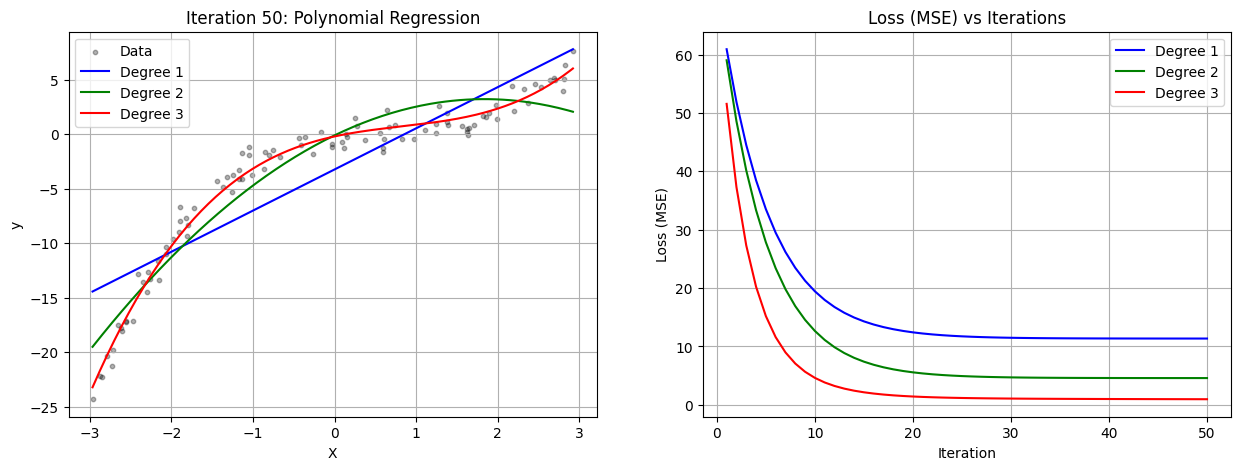

✅ Training complete


In [9]:
#  ==========================================
#   Polynomial Regression - Simulated Data (Setting: 50, 0.001)
#  ==========================================

# Polynomial Regression with degrees 1–3
# Iteration-by-iteration visualization in Colab

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import clear_output, display
import time

# -------------------------------
# 1) Generate a synthetic dataset (1 input, 1 output)
# -------------------------------
np.random.seed(42)
X = 6 * np.random.rand(100, 1) - 3   # input feature (100x1)
y = 0.5 * X**3 - X**2 + X + np.random.randn(100, 1)  # cubic with noise
y = y.ravel()  # ensure target is 1D (100,)

# -------------------------------
# 2) User input for iterations and learning rate
# -------------------------------
total_iters = int(input("Enter total number of iterations: "))
eta = float(input("Enter learning rate (e.g., 0.01): "))

# -------------------------------
# 3) Prepare polynomial features and scalers
# -------------------------------
degrees = [1, 2, 3]
poly_features = {d: PolynomialFeatures(degree=d, include_bias=False) for d in degrees}
scalers = {d: StandardScaler() for d in degrees}

X_poly = {d: poly_features[d].fit_transform(X) for d in degrees}
X_scaled = {d: scalers[d].fit_transform(X_poly[d]) for d in degrees}

# -------------------------------
# 4) Initialize SGD models (built-in)
# -------------------------------
sgd_models = {
    d: SGDRegressor(max_iter=1, tol=None, learning_rate="constant",
                    eta0=eta, random_state=42)
    for d in degrees
}
loss_history = {d: [] for d in degrees}

# -------------------------------
# 5) Grid for regression curves
# -------------------------------
X_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_grid_poly = {d: poly_features[d].transform(X_grid) for d in degrees}
X_grid_scaled = {d: scalers[d].transform(X_grid_poly[d]) for d in degrees}

# -------------------------------
# 6) Iterative training loop
# -------------------------------
colors = {1: "blue", 2: "green", 3: "red", 4: "purple"}

for iteration in range(1, total_iters + 1):
    # Train models and record loss
    for d in degrees:
        sgd_models[d].partial_fit(X_scaled[d], y)
        y_pred = sgd_models[d].predict(X_scaled[d])
        loss = mean_squared_error(y, y_pred)
        loss_history[d].append(loss)

    # -------------------------------
    # Visualization
    # -------------------------------
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Left: Regression curves
    axes[0].scatter(X, y, color="black", alpha=0.3, label="Data", s=10)
    for d in degrees:
        y_grid_pred = sgd_models[d].predict(X_grid_scaled[d])
        axes[0].plot(X_grid, y_grid_pred, color=colors[d], label=f"Degree {d}")
    axes[0].set_title(f"Iteration {iteration}: Polynomial Regression")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("y")
    axes[0].legend()
    axes[0].grid(True)

    # Right: Loss curves
    for d in degrees:
        axes[1].plot(range(1, len(loss_history[d]) + 1), loss_history[d],
                     color=colors[d], label=f"Degree {d}")
    axes[1].set_title("Loss (MSE) vs Iterations")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Loss (MSE)")
    axes[1].legend()
    axes[1].grid(True)

    display(fig)
    plt.close(fig)
    time.sleep(0.3)  # adjust animation speed

print("✅ Training complete")
